---
# La poule qui chante  
### Étude de marché international pour les *Poulets Agriculture Biologique*  
#### Phase 1 – Préparation et nettoyage des données---


## 1) Imports & options d'affichage

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

print("✅ Imports OK")


✅ Imports OK


## 2) Chargement des fichiers sources (CSV nettoyés)

In [5]:
import os
import pandas as pd

DATA_DIR = "01_sources_csv"

def read_csv_safe(path, preferred_sep=None, encodings=("utf-8","utf-8-sig")):
    """
    Lecture robuste d'un CSV :
    - tente d'abord le séparateur 'preferred_sep' si fourni
    - puis essaie une liste de séparateurs usuels avec encodages variés
    - en dernier recours, laisse pandas inférer avec engine='python'
    """
    basename = os.path.basename(path)
    tried = []

    # 1) Essai prioritaire avec preferred_sep si fourni
    if preferred_sep is not None:
        for enc in encodings:
            try:
                df = pd.read_csv(path, sep=preferred_sep, encoding=enc, low_memory=False)
                print(f"✅ lu: {basename} (sep='{preferred_sep}', enc='{enc}') -> {df.shape[0]} lignes, {df.shape[1]} colonnes")
                return df
            except Exception as e:
                tried.append((preferred_sep, enc, repr(e)))

    # 2) Essais alternatifs
    seps = [",",";","\t","|"]
    for sep in seps:
        for enc in encodings:
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc, low_memory=False)
                print(f"✅ lu: {basename} (sep='{sep}', enc='{enc}') -> {df.shape[0]} lignes, {df.shape[1]} colonnes")
                return df
            except Exception as e:
                tried.append((sep, enc, repr(e)))

    # 3) Ultime essai : inférence avec engine='python' (sans low_memory)
    try:
        df = pd.read_csv(path, engine="python")
        print(f"✅ lu (inférence): {basename} -> {df.shape[0]} lignes, {df.shape[1]} colonnes")
        return df
    except Exception as e:
        # Petit diagnostic utile
        print(f"❌ Échecs pour {basename}:")
        for sep, enc, err in tried[:6]:
            print(f"   - sep='{sep}', enc='{enc}' -> {err}")
        raise e

# --- FAO ---
fao_pop  = read_csv_safe(f"{DATA_DIR}/FAO/Population_2000_2018.csv", preferred_sep=";")
fao_food = read_csv_safe(f"{DATA_DIR}/FAO/DisponibiliteAlimentaire_2017.csv", preferred_sep=";")

# --- World Bank (selon tes nettoyages, ça peut être ',' OU ';')
wb_gdp = read_csv_safe(f"{DATA_DIR}/WB/wb_gdp_per_capita_2017.csv")   # pas de preferred_sep -> auto
wb_urb = read_csv_safe(f"{DATA_DIR}/WB/wb_urban_pop_2017.csv")         # pas de preferred_sep -> auto
wb_gov = read_csv_safe(f"{DATA_DIR}/WB/wb_indice_gouvernance_2017_clean.csv", preferred_sep=";")

# --- Heritage & FiBL ---
heritage = read_csv_safe(f"{DATA_DIR}/Heritage/heritage_trade_freedom_2017.csv")  # auto
fibl     = read_csv_safe(f"{DATA_DIR}/FiBL/fibl_surface_agri_bio_2017_pct.csv", preferred_sep=";")

# --- Récapitulatif ---
datasets = {
    "fao_pop": fao_pop, "fao_food": fao_food,
    "wb_gdp": wb_gdp, "wb_urb": wb_urb, "wb_gov": wb_gov,
    "heritage": heritage, "fibl": fibl
}

print("\n------ RÉSUMÉ CHARGEMENT ------")
for name, df in datasets.items():
    print(f"{name:>10} : {df.shape} | colonnes -> {list(df.columns)[:6]}{' ...' if df.shape[1] > 6 else ''}")

# --- Sanity check : 'iso3' présent partout ---
for name, df in datasets.items():
    assert "iso3" in df.columns, f"❌ 'iso3' manquant dans {name} (vérifie que tu as bien ajouté iso3 dans Excel)"
print("\n✅ Chargements OK + clé 'iso3' présente dans tous les fichiers")


✅ lu: Population_2000_2018.csv (sep=';', enc='utf-8') -> 4411 lignes, 16 colonnes
✅ lu: DisponibiliteAlimentaire_2017.csv (sep=';', enc='utf-8') -> 176600 lignes, 15 colonnes
✅ lu: wb_gdp_per_capita_2017.csv (sep=';', enc='utf-8') -> 210 lignes, 3 colonnes
✅ lu: wb_urban_pop_2017.csv (sep=';', enc='utf-8') -> 215 lignes, 3 colonnes
✅ lu: wb_indice_gouvernance_2017_clean.csv (sep=';', enc='utf-8') -> 202 lignes, 3 colonnes
✅ lu: heritage_trade_freedom_2017.csv (sep=';', enc='utf-8') -> 185 lignes, 3 colonnes
✅ lu: fibl_surface_agri_bio_2017_pct.csv (sep=';', enc='utf-8') -> 169 lignes, 3 colonnes

------ RÉSUMÉ CHARGEMENT ------
   fao_pop : (4411, 16) | colonnes -> ['Code Domaine', 'Domaine', 'Code zone', 'iso3', 'Zone', 'Code Élément'] ...
  fao_food : (176600, 15) | colonnes -> ['Code Domaine', 'Domaine', 'Code zone', 'iso3', 'Zone', 'Code Élément'] ...
    wb_gdp : (210, 3) | colonnes -> ['country_clean', 'iso3', 'gdp_per_capita_2017_usd']
    wb_urb : (215, 3) | colonnes -> ['count

## 3) Inspection & petits nettoyages typages

In [7]:
# ========================================
# 🔎 Exploration du contenu FAO : Élément & Produit
# ========================================

# On se limite au dataset FAO des disponibilités alimentaires
dfa = fao_food.copy()

# Vérifier les colonnes présentes
print("Colonnes FAO :", list(dfa.columns))

# Nombre de lignes et années couvertes
print("\nNombre total de lignes :", len(dfa))
print("Années uniques :", sorted(dfa["Code année"].unique())[:10], "...")

# Aperçu général
display(dfa.head(3))

# --- 1️⃣ Liste unique des éléments FAO (colonne 'Élément') ---
if "Élément" in dfa.columns:
    print("\n💡 Liste des éléments disponibles (FAO 'Élément'):")
    elems = dfa["Élément"].dropna().unique()
    for e in sorted(elems)[:30]:  # affiche les 30 premiers
        print("-", e)
    print(f"\nTotal unique : {len(elems)} éléments FAO")
else:
    print("⚠️ Colonne 'Élément' introuvable — vérifie l'encodage du CSV.")

# --- 2️⃣ Liste unique des produits FAO (colonne 'Produit') ---
if "Produit" in dfa.columns:
    print("\n💡 Liste des produits disponibles (FAO 'Produit'):")
    prods = dfa["Produit"].dropna().unique()
    for p in sorted(prods)[:40]:  # affiche les 40 premiers
        print("-", p)
    print(f"\nTotal unique : {len(prods)} produits FAO")
else:
    print("⚠️ Colonne 'Produit' introuvable — vérifie l'encodage du CSV.")

# --- 3️⃣ Rechercher tous les produits contenant "volaille", "poulet", "poultry" ---
mask_vol = dfa["Produit"].str.contains("volaille|poulet|poultry", case=False, na=False)
produits_volaille = sorted(dfa.loc[mask_vol, "Produit"].unique())
print("\n🐔 Produits FAO contenant 'volaille' ou 'poulet' :")
for p in produits_volaille:
    print("-", p)

# --- 4️⃣ Rechercher tous les éléments associés à la volaille ---
elems_vol = sorted(dfa.loc[mask_vol, "Élément"].unique())
print("\n📦 Éléments FAO associés à la volaille :")
for e in elems_vol:
    print("-", e)


Colonnes FAO : ['Code Domaine', 'Domaine', 'Code zone', 'iso3', 'Zone', 'Code Élément', 'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité', 'Valeur', 'Symbole', 'Description du Symbole']

Nombre total de lignes : 176600
Années uniques : [2017] ...


,Code Domaine,Domaine,Code zone,iso3,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,AFG,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,AFG,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,AFG,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées



💡 Liste des éléments disponibles (FAO 'Élément'):
- Alimentation pour touristes
- Aliments pour animaux
- Autres utilisations (non alimentaire)
- Disponibilité alimentaire (Kcal/personne/jour)
- Disponibilité alimentaire en quantité (kg/personne/an)
- Disponibilité de matière grasse en quantité (g/personne/jour)
- Disponibilité de protéines en quantité (g/personne/jour)
- Disponibilité intérieure
- Exportations - Quantité
- Importations - Quantité
- Nourriture
- Pertes
- Production
- Résidus
- Semences
- Traitement
- Variation de stock

Total unique : 17 éléments FAO

💡 Liste des produits disponibles (FAO 'Produit'):
- Abats Comestible
- Agrumes, Autres
- Alcool, non Comestible
- Aliments pour enfants
- Ananas et produits
- Animaux Aquatiques Autre
- Arachides Decortiquees
- Avoine
- Bananes
- Bananes plantains
- Beurre, Ghee
- Bière
- Blé et produits
- Boissons Alcooliques
- Boissons Fermentés
- Café et produits
- Cephalopodes
- Citrons & Limes et produits
- Coco (Incl Coprah)
- Crus

In [8]:
def to_float_safely(s):
    """Convertit des nombres qui peuvent contenir des virgules décimales en float."""
    return (s.astype(str)
             .str.replace("\u00A0", "", regex=False)  # espace insécable éventuel
             .str.replace(" ", "", regex=False)       # espaces
             .str.replace(",", ".", regex=False)      # virgule -> point
             .replace({"": None})
             .astype(float))

# --- 3.a Harmonisation des noms de colonnes utiles ---
# Heritage: renommer "Trade Freedom" -> trade_freedom_2017
if "Trade Freedom" in heritage.columns:
    heritage = heritage.rename(columns={"Trade Freedom": "trade_freedom_2017"})

# Nettoyage éventuel d'espaces dans 'country_clean'
for df in [wb_gdp, wb_urb, wb_gov, heritage, fibl]:
    if "country_clean" in df.columns:
        df["country_clean"] = df["country_clean"].astype(str).str.strip()

# --- 3.b Conversions numériques robustes ---
# GDP per capita
if "gdp_per_capita_2017_usd" in wb_gdp.columns:
    wb_gdp["gdp_per_capita_2017_usd"] = to_float_safely(wb_gdp["gdp_per_capita_2017_usd"])

# Urban population %
if "urban_pop_2017_pct" in wb_urb.columns:
    wb_urb["urban_pop_2017_pct"] = to_float_safely(wb_urb["urban_pop_2017_pct"])

# Governance index
if "governance_index_mean" in wb_gov.columns:
    wb_gov["governance_index_mean"] = to_float_safely(wb_gov["governance_index_mean"])

# Heritage trade freedom
if "trade_freedom_2017" in heritage.columns:
    heritage["trade_freedom_2017"] = to_float_safely(heritage["trade_freedom_2017"])

# FiBL organic share %
if "organic_agri_share_pct" in fibl.columns:
    fibl["organic_agri_share_pct"] = to_float_safely(fibl["organic_agri_share_pct"])

# --- 3.c Unicité sur iso3 pour toutes les sources “slim” (au cas où) ---
def dedupe_on_iso3(df, keep="first"):
    if "iso3" not in df.columns:
        return df
    before = df.shape[0]
    df = df.sort_values("iso3").drop_duplicates(subset=["iso3"], keep=keep)
    after = df.shape[0]
    if after < before:
        print(f"ℹ️  {before-after} doublon(s) supprimé(s) sur 'iso3' ({before} -> {after})")
    return df

wb_gdp = dedupe_on_iso3(wb_gdp)
wb_urb = dedupe_on_iso3(wb_urb)
wb_gov = dedupe_on_iso3(wb_gov)
heritage = dedupe_on_iso3(heritage)
fibl = dedupe_on_iso3(fibl)

# --- 3.d Petits aperçus & NA rates ---
def na_rate(df):
    return (df.isna().mean()*100).round(1)

print("\nAperçu typage & NA (%) :")
for name, df in [("wb_gdp", wb_gdp), ("wb_urb", wb_urb), ("wb_gov", wb_gov),
                 ("heritage", heritage), ("fibl", fibl)]:
    print(f"\n{name} -> {df.shape}")
    print(df.dtypes)
    print("NA %:\n", na_rate(df)[na_rate(df)>0])

# Check rapide FAO
print("\nFAO pop colonnes (extrait) :", list(fao_pop.columns)[:10])
print("FAO food colonnes (extrait):", list(fao_food.columns)[:10])

print("\n✅ Cellule 4 OK : colonnes renommées, numériques converties, doublons iso3 supprimés.")


ℹ️  5 doublon(s) supprimé(s) sur 'iso3' (169 -> 164)

Aperçu typage & NA (%) :

wb_gdp -> (210, 3)
country_clean               object
iso3                        object
gdp_per_capita_2017_usd    float64
dtype: object
NA %:
 Series([], dtype: float64)

wb_urb -> (215, 3)
country_clean          object
iso3                   object
urban_pop_2017_pct    float64
dtype: object
NA %:
 urban_pop_2017_pct    0.5
dtype: float64

wb_gov -> (202, 3)
iso3                      object
country_clean             object
governance_index_mean    float64
dtype: object
NA %:
 Series([], dtype: float64)

heritage -> (185, 3)
iso3                   object
country_clean          object
trade_freedom_2017    float64
dtype: object
NA %:
 trade_freedom_2017    1.6
dtype: float64

fibl -> (164, 3)
country_clean              object
iso3                       object
organic_agri_share_pct    float64
dtype: object
NA %:
 iso3                      0.6
organic_agri_share_pct    0.6
dtype: float64

FAO pop colonnes (

## 4) Nouvelle variable - Croissance démographique 2000–2017 (%)

Création d'une nouvelle variable : croissance de la population entre 2000 et 2017 (en pourcentage)

In [11]:
import numpy as np
import pandas as pd

# --- 0️⃣ Format d'affichage : pas de notation scientifique ---
pd.options.display.float_format = "{:,.0f}".format

# --- 1️⃣ Sous-ensemble des années 2000 et 2017 ---
fao_pop_sub = fao_pop[fao_pop["Code année"].isin([2000, 2017])].copy()

# --- 2️⃣ Identifier la colonne contenant les valeurs de population ---
val_col = next((c for c in fao_pop_sub.columns if "Valeur" in c or "Value" in c), None)
if val_col is None:
    raise ValueError("Impossible de repérer la colonne contenant les valeurs de population")

# --- 3️⃣ Pivot pour avoir une colonne par année ---
pop_pivot = (
    fao_pop_sub
    .pivot_table(index="iso3", columns="Code année", values=val_col, aggfunc="first")
    .rename(columns={2000: "pop_2000", 2017: "pop_2017"})
    .reset_index()
)

# --- 4️⃣ Conversion en float + passage en HABITANTS (FAO = milliers d’habitants) ---
for c in ["pop_2000", "pop_2017"]:
    pop_pivot[c] = pd.to_numeric(pop_pivot[c], errors="coerce") * 1_000  # conversion en habitants

# --- 5️⃣ Calcul du taux de croissance (%)
pop_pivot["population_growth_2000_2017_pct"] = np.where(
    pop_pivot["pop_2000"] > 0,
    (pop_pivot["pop_2017"] - pop_pivot["pop_2000"]) / pop_pivot["pop_2000"] * 100,
    np.nan
)

# --- 6️⃣ Vérifications rapides ---
print("✅ Croissance population calculée :", pop_pivot.shape)
print("⚙️  Les populations sont désormais exprimées en habitants (pas en milliers)")
display(pop_pivot.head(10))


✅ Croissance population calculée : (233, 4)
⚙️  Les populations sont désormais exprimées en habitants (pas en milliers)


Code année,iso3,pop_2000,pop_2017,population_growth_2000_2017_pct
0,ABW,"90,853","105,366",16
1,AFG,"20,779,953","36,296,113",75
2,AGO,"16,395,473","29,816,766",82
3,AIA,"11,252","14,584",30
4,ALB,"3,129,243","2,884,169",-8
5,AND,"65,390","77,001",18
6,ARE,"3,134,062","9,487,203",203
7,ARG,"36,870,787","43,937,140",19
8,ARM,"3,069,591","2,944,791",-4
9,ASM,"57,821","55,620",-4


## 5) Fusion finale (clé = iso3)

### 5.a — Préparer un label pays lisible (priorité FAO, sinon WB)

In [14]:
label_fao = (fao_pop[["iso3", "Zone"]]
             .drop_duplicates("iso3")
             .rename(columns={"Zone": "country_label"}))
label_wb  = None
for df in [wb_gdp, wb_urb, wb_gov, heritage, fibl]:
    if "country_clean" in df.columns:
        label_wb = df[["iso3", "country_clean"]].drop_duplicates("iso3")
        break
if label_wb is not None:
    label_wb = label_wb.rename(columns={"country_clean": "country_label"})

# priorité au label FAO, fallback WB si manquant
labels = label_fao.copy()
if label_wb is not None:
    labels = (labels.merge(label_wb, on="iso3", how="outer", suffixes=("_fao", "_wb"))
                    .assign(country_label=lambda x: x["country_label_fao"].fillna(x["country_label_wb"]))
                    [["iso3", "country_label"]])

### 5.b — Construire des versions “slim” des tables (iso3 + variable)

In [16]:
gdp_slim = wb_gdp[["iso3", "gdp_per_capita_2017_usd"]] if "gdp_per_capita_2017_usd" in wb_gdp.columns else None
urb_slim = wb_urb[["iso3", "urban_pop_2017_pct"]]      if "urban_pop_2017_pct" in wb_urb.columns else None
gov_slim = wb_gov[["iso3", "governance_index_mean"]]    if "governance_index_mean" in wb_gov.columns else None
trd_slim = heritage[["iso3", "trade_freedom_2017"]]     if "trade_freedom_2017" in heritage.columns else None
bio_slim = fibl[["iso3", "organic_agri_share_pct"]]     if "organic_agri_share_pct" in fibl.columns else None


### 5.c — Fusionner sur iso3 (base = pop_pivot)

In [18]:
base = pop_pivot.merge(labels, on="iso3", how="left")
for slim in [gdp_slim, urb_slim, gov_slim, trd_slim, bio_slim]:
    if slim is not None:
        base = base.merge(slim, on="iso3", how="left")

### 5.d — Ordonner les colonnes (on garde celles existantes)

In [20]:
cols_order = [
    "iso3", "country_label",
    "pop_2000", "pop_2017", "population_growth_2000_2017_pct",
    "gdp_per_capita_2017_usd",
    "urban_pop_2017_pct",
    "governance_index_mean",
    "trade_freedom_2017",
    "organic_agri_share_pct",
]
base = base[[c for c in cols_order if c in base.columns]]


### 5.e — Contrôles rapides : taille, lignes manquantes, taux de NA

In [22]:
print("📦 Dimensions du dataset final :", base.shape)
na_rate = (base.isna().mean()*100).round(1)
print("\nTaux de valeurs manquantes (%) :")
display(na_rate.to_frame("missing_%").T)

📦 Dimensions du dataset final : (233, 10)

Taux de valeurs manquantes (%) :


,iso3,country_label,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct
missing_%,0,0,4,0,4,11,8,14,22,30


### 5.f — Aperçu

In [24]:
display(base.head(12))

,iso3,country_label,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct
0,ABW,Aruba,"90,853","105,366",16,"28,440",43,1,NaN,NaN
1,AFG,Afghanistan,"20,779,953","36,296,113",75,525,25,-2,66,0
2,AGO,Angola,"16,395,473","29,816,766",82,"2,437",65,-1,57,NaN
3,AIA,Anguilla,"11,252","14,584",30,NaN,NaN,NaN,NaN,NaN
4,ALB,Albanie,"3,129,243","2,884,169",-8,"4,614",59,0,88,0
5,AND,Andorre,"65,390","77,001",18,"40,673",88,1,NaN,0
6,ARE,Émirats arabes unis,"3,134,062","9,487,203",203,"42,341",86,1,84,1
7,ARG,Argentine,"36,870,787","43,937,140",19,"14,533",92,0,67,3
8,ARM,Arménie,"3,069,591","2,944,791",-4,"3,869",63,-0,80,0
9,ASM,Samoa américaines,"57,821","55,620",-4,"11,864",87,NaN,NaN,NaN


### 5.g — Export CSV intermédiaire

In [26]:
out_path = "P11_dataset_final.csv"
base.to_csv(out_path, index=False, encoding="utf-8")
print(f"💾 Exporté : {out_path}")


💾 Exporté : P11_dataset_final.csv


### 5.h - Ajout des données de la base FAO volaille 

On va rajouter les indicateurs relatifs à la volaille (production, importation, exportation) exprimés en milliers de tonnes.
Ainsi que la disponibilité de volaille (exprimée en kcal par jour). 

In [29]:
import unicodedata
import numpy as np
import pandas as pd

def _norm(s):
    """Normalise le texte (supprime accents et met en minuscule)."""
    def n(x):
        x = unicodedata.normalize("NFKD", str(x))
        x = x.encode("ascii", "ignore").decode("ascii")
        return x.lower().strip()
    return s.apply(n)

# 1) Sous-ensemble 2017 + normalisation
ffa = fao_food[fao_food["Code année"] == 2017].copy()

# repérage de la colonne valeur (fr/en)
val_col = next((c for c in ffa.columns if "Valeur" in c or c.lower()=="value"), None)
if val_col is None:
    raise ValueError("Colonne valeur introuvable dans fao_food (pas de 'Valeur' ni 'Value').")

ffa["elem_n"] = _norm(ffa["Élément"] if "Élément" in ffa.columns else ffa["Element"])
ffa["prod_n"] = _norm(ffa["Produit"] if "Produit" in ffa.columns else ffa["Item"])

# 2) Filtres robustes
#   - Eléments
is_prod   = ffa["elem_n"].str.contains(r"\bproduction\b")
is_imp_q  = ffa["elem_n"].str.contains("import") & ffa["elem_n"].str.contains("quant")
is_exp_q  = ffa["elem_n"].str.contains("export") & ffa["elem_n"].str.contains("quant")
is_kcal   = ffa["elem_n"].str.contains("kcal.*jour") | ffa["elem_n"].str.contains("kcal.*capita")

#   - Produits "volaille"
is_poultry = (
    ffa["prod_n"].str.contains("volaille") |
    ffa["prod_n"].str.contains("poulet")   |
    ffa["prod_n"].str.contains("poultry")
)

# 3) Agrégations par iso3
def agg_sum(df):
    return df.groupby("iso3", as_index=False)[val_col].sum()

prod_vol = agg_sum(ffa[is_prod & is_poultry]).rename(columns={val_col: "production_volaille"})
imp_vol  = agg_sum(ffa[is_imp_q & is_poultry]).rename(columns={val_col: "import_volaille"})
exp_vol  = agg_sum(ffa[is_exp_q & is_poultry]).rename(columns={val_col: "export_volaille"})
dispo_vol_kcal = agg_sum(ffa[is_kcal & is_poultry]).rename(columns={val_col: "dispo_volaille_kcal_jour"})

# 4) Fusion intermédiaire FAO volaille (sans "dispo_totale_kcal_jour")
fao_vol = (
    prod_vol.merge(imp_vol, on="iso3", how="outer")
            .merge(exp_vol, on="iso3", how="outer")
            .merge(dispo_vol_kcal, on="iso3", how="outer")
)

# 5) Types numériques + unités
for c in ["production_volaille","import_volaille","export_volaille","dispo_volaille_kcal_jour"]:
    if c in fao_vol.columns:
        fao_vol[c] = pd.to_numeric(fao_vol[c], errors="coerce")

# 6) Fusion au dataset final "base"
base = base.merge(fao_vol, on="iso3", how="left")

# 7) Contrôles et aperçu
print("📦 Dimensions après ajout FAO volaille :", base.shape)
na_rate = (base.isna().mean()*100).round(1)
display(na_rate[[
    "gdp_per_capita_2017_usd", "urban_pop_2017_pct", "governance_index_mean",
    "trade_freedom_2017", "organic_agri_share_pct",
    "production_volaille", "import_volaille", "export_volaille", "dispo_volaille_kcal_jour"
]].to_frame("missing_%").T)

display(base.sample(8, random_state=42))


📦 Dimensions après ajout FAO volaille : (233, 14)


,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
missing_%,11,8,14,22,30,28,27,42,26


,iso3,country_label,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
84,GRL,Groenland,"56,175","56,481",1,"50,766",87,1,NaN,NaN,NaN,NaN,NaN,NaN
216,UKR,Ukraine,"48,838,065","44,487,709",-9,"2,604",69,-1,86,1,"1,211",121,273,78
231,ZMB,Zambie,"10,415,944","16,853,599",62,"1,483",43,-0,78,0,49,12,1,11
9,ASM,Samoa américaines,"57,821","55,620",-4,"11,864",87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,MAF,Saint-Martin (partie française),NaN,"36,560",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,EGY,Égypte,"68,831,561","96,442,591",40,"2,395",43,-1,70,3,"1,118",110,1,50
55,DMA,Dominique,"69,650","71,458",3,"8,225",70,1,73,1,0,4,0,150
198,SYC,Seychelles,"80,996","96,418",19,"17,480",56,0,83,NaN,NaN,NaN,NaN,NaN


### 5.l - Export du dataset enrichi

In [31]:
out_path = "P11_dataset_final.csv"
base.to_csv(out_path, index=False, encoding="utf-8")
print(f"💾 Exporté (avec les données FAO - volaille uniquement) : {out_path}")

💾 Exporté (avec les données FAO - volaille uniquement) : P11_dataset_final.csv


## 6) Analyse exploratoire du dataset final

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt


### 6.a - Chargement du dataset final propre (si besoin)

In [35]:
df = base.copy()  # base vient des cellules précédentes
# si tu relances indépendamment :
# df = pd.read_csv("P11_dataset_final.csv", encoding="utf-8")

print("✅ Dataset chargé :", df.shape)
display(df.head(5))


✅ Dataset chargé : (233, 14)


,iso3,country_label,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
0,ABW,Aruba,"90,853","105,366",16,"28,440",43,1,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,"20,779,953","36,296,113",75,525,25,-2,66,0,28,29,NaN,5
2,AGO,Angola,"16,395,473","29,816,766",82,"2,437",65,-1,57,NaN,42,277,0,35
3,AIA,Anguilla,"11,252","14,584",30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ALB,Albanie,"3,129,243","2,884,169",-8,"4,614",59,0,88,0,13,38,0,85


### 7.b - Vérification des types de variables

In [37]:
print("\nTypes de variables :")
print(df.dtypes)



Types de variables :
iso3                                object
country_label                       object
pop_2000                           float64
pop_2017                           float64
population_growth_2000_2017_pct    float64
gdp_per_capita_2017_usd            float64
urban_pop_2017_pct                 float64
governance_index_mean              float64
trade_freedom_2017                 float64
organic_agri_share_pct             float64
production_volaille                float64
import_volaille                    float64
export_volaille                    float64
dispo_volaille_kcal_jour           float64
dtype: object


### 7.c - Statistiques descriptives

In [39]:
desc = df.describe().T
desc["missing_%"] = df.isna().mean() * 100
display(desc)


,count,mean,std,min,25%,50%,75%,max,missing_%
pop_2000,224,"27,230,126","115,137,718",785,"407,906","4,463,721","16,043,509","1,290,550,765",4
pop_2017,233,"32,393,495","132,694,911",793,"424,473","5,447,900","19,653,969","1,421,021,791",0
population_growth_2000_2017_pct,224,29,37,-19,7,22,46,360,4
gdp_per_capita_2017_usd,208,"17,962","26,139",237,"2,349","6,583","23,460","170,663",11
urban_pop_2017_pct,214,61,24,13,42,62,80,100,8
governance_index_mean,201,-0,1,-2,-1,-0,1,2,14
trade_freedom_2017,182,76,12,0,69,78,86,90,22
organic_agri_share_pct,162,3,6,0,0,1,3,39,30
production_volaille,168,725,"2,501",0,14,70,410,"21,914",28
import_volaille,170,90,187,0,3,16,81,"1,069",27


### 7.d - Complétude par pays + filtrage strict

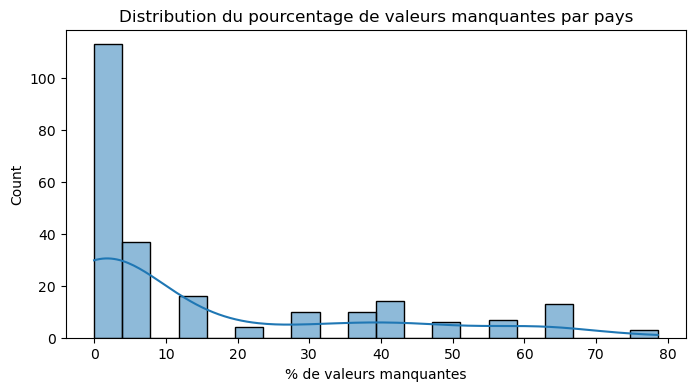

count   233
mean     15
std      22
min       0
25%       0
50%       7
75%      29
max      79
Name: missing_pct, dtype: float64

✅ Pays conservés après suppression des NaN : 113 sur 233 (48.5 %)
🌍 Couverture population mondiale : 85.7 %


,iso3,country_label,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
4,ALB,Albanie,"3,129,243","2,884,169",-8,"4,614",59,0,88,0,13,38,0,85
6,ARE,Émirats arabes unis,"3,134,062","9,487,203",203,"42,341",86,1,84,1,48,433,94,147
7,ARG,Argentine,"36,870,787","43,937,140",19,"14,533",92,0,67,3,"2,161",8,207,182
8,ARM,Arménie,"3,069,591","2,944,791",-4,"3,869",63,-0,80,0,11,35,0,54
11,AUS,Australie,"18,991,431","24,584,620",29,"53,902",86,2,86,10,"1,269",16,42,192


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# df a déjà été défini plus haut comme une copie de base :
# df = base.copy()

# 1️⃣ Calcul du % de valeurs manquantes par pays
df["missing_pct"] = df.isna().mean(axis=1) * 100

# Histogramme de la complétude
plt.figure(figsize=(8,4))
sns.histplot(df["missing_pct"], bins=20, kde=True)
plt.title("Distribution du pourcentage de valeurs manquantes par pays")
plt.xlabel("% de valeurs manquantes")
plt.show()

print(df["missing_pct"].describe())

# 2️⃣ Filtrage strict : on garde uniquement les pays sans aucune valeur manquante
df_no_na = df[df["missing_pct"] == 0].copy()

print(f"\n✅ Pays conservés après suppression des NaN : {df_no_na.shape[0]} sur {df.shape[0]} "
      f"({df_no_na.shape[0]/df.shape[0]*100:.1f} %)")

# 3️⃣ Vérification de la couverture population mondiale
total_world_2017 = df["pop_2017"].sum()
filtered_world_2017 = df_no_na["pop_2017"].sum()
coverage_pct = (filtered_world_2017 / total_world_2017) * 100

print(f"🌍 Couverture population mondiale : {coverage_pct:.1f} %")

# 4️⃣ Retirer la colonne technique 'missing_pct' du dataset filtré
df_no_na = df_no_na.drop(columns=["missing_pct"])

# 5️⃣ Aperçu et export
display(df_no_na.head())


### 7.e - Export du dataset filtré (sans NaN)

In [43]:
df_no_na.to_csv("P11_dataset_filtered_strict.csv", index=False, encoding="utf-8")
print("💾 Exporté : P11_dataset_filtered_strict.csv")


💾 Exporté : P11_dataset_filtered_strict.csv


## 8) Nettoyage final des colonnes pour ACP

### 8.a - Colonne renommée et suppression de la colonne Iso3

In [46]:
df_clean = df_no_na.copy()

# 1) Renommer country_label → country
df_clean = df_clean.rename(columns={"country_label": "country"})

# 2) Supprimer iso3 (inutile pour ACP / clustering)
if "iso3" in df_clean.columns:
    df_clean = df_clean.drop(columns=["iso3"])

print("📦 Dimensions après nettoyage final :", df_clean.shape)
print("Colonnes conservées :")
print(df_clean.columns.tolist())

# Aperçu
display(df_clean.head())

📦 Dimensions après nettoyage final : (113, 13)
Colonnes conservées :
['country', 'pop_2000', 'pop_2017', 'population_growth_2000_2017_pct', 'gdp_per_capita_2017_usd', 'urban_pop_2017_pct', 'governance_index_mean', 'trade_freedom_2017', 'organic_agri_share_pct', 'production_volaille', 'import_volaille', 'export_volaille', 'dispo_volaille_kcal_jour']


,country,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
4,Albanie,"3,129,243","2,884,169",-8,"4,614",59,0,88,0,13,38,0,85
6,Émirats arabes unis,"3,134,062","9,487,203",203,"42,341",86,1,84,1,48,433,94,147
7,Argentine,"36,870,787","43,937,140",19,"14,533",92,0,67,3,"2,161",8,207,182
8,Arménie,"3,069,591","2,944,791",-4,"3,869",63,-0,80,0,11,35,0,54
11,Australie,"18,991,431","24,584,620",29,"53,902",86,2,86,10,"1,269",16,42,192


### 8.b - Feature engineering : correction de l’effet taille
Création d’indicateurs volaille par million d'habitant (FAO, 2017)

In [48]:
df_clean["production_volaille_per_million"] = (
    df_clean["production_volaille"] / df_clean["pop_2017"] * 1_000_000
)

df_clean["export_volaille_per_million"] = (
    df_clean["export_volaille"] / df_clean["pop_2017"] * 1_000_000
)

df_clean["import_volaille_per_million"] = (
    df_clean["import_volaille"] / df_clean["pop_2017"] * 1_000_000
)


Les indicateurs ont été rapportés à la population et exprimés par million d’habitants afin d’améliorer la lisibilité sans modifier l’analyse statistique

### 8.c - Nettoyage final des variables
Suppression des volumes totaux devenus redondants (production_volaille / export_volaille / import_volaille) ou inutile (pop_2000)

In [51]:
df_clean = df_clean.drop(columns=[
    "production_volaille",
    "export_volaille",
    "import_volaille",
    "pop_2000"
])

### 8.d - Vérifications finales

Quel est le % de valeurs manquantes par colonne ?

In [54]:
df_clean.isna().mean()

country                           0
pop_2017                          0
population_growth_2000_2017_pct   0
gdp_per_capita_2017_usd           0
urban_pop_2017_pct                0
governance_index_mean             0
trade_freedom_2017                0
organic_agri_share_pct            0
dispo_volaille_kcal_jour          0
production_volaille_per_million   0
export_volaille_per_million       0
import_volaille_per_million       0
dtype: float64

Y a-t-il des lignes en double ?

In [56]:
df_clean.duplicated().sum()

0

La méthode `info` nous donne des indications globales :

In [58]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 4 to 231
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          113 non-null    object 
 1   pop_2017                         113 non-null    float64
 2   population_growth_2000_2017_pct  113 non-null    float64
 3   gdp_per_capita_2017_usd          113 non-null    float64
 4   urban_pop_2017_pct               113 non-null    float64
 5   governance_index_mean            113 non-null    float64
 6   trade_freedom_2017               113 non-null    float64
 7   organic_agri_share_pct           113 non-null    float64
 8   dispo_volaille_kcal_jour         113 non-null    float64
 9   production_volaille_per_million  113 non-null    float64
 10  export_volaille_per_million      113 non-null    float64
 11  import_volaille_per_million      113 non-null    float64
dtypes: float64(11), object(1)
m

Combien y a-t-il de valeurs différentes par colonne ?

In [60]:
df_clean.nunique()

country                            113
pop_2017                           113
population_growth_2000_2017_pct    113
gdp_per_capita_2017_usd            113
urban_pop_2017_pct                 113
governance_index_mean              113
trade_freedom_2017                  74
organic_agri_share_pct              89
dispo_volaille_kcal_jour            84
production_volaille_per_million    110
export_volaille_per_million         81
import_volaille_per_million        102
dtype: int64

Enfin la methode `describe` nous donne une idée de la dispersion globale de nos données :

In [62]:
df_clean.shape
df_clean.isna().sum()
df_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
pop_2017,113,"57,251,612","186,553,869","71,458","4,665,928","10,569,450","41,389,189","1,421,021,791"
population_growth_2000_2017_pct,113,25,30,-19,7,19,35,203
gdp_per_capita_2017_usd,113,"17,448","20,993",522,"3,799","8,225","23,303","110,193"
urban_pop_2017_pct,113,64,20,16,51,67,80,100
governance_index_mean,113,0,1,-1,-0,-0,1,2
trade_freedom_2017,113,80,8,53,74,82,87,90
organic_agri_share_pct,113,3,6,0,0,1,3,38
dispo_volaille_kcal_jour,113,80,52,2,47,71,107,234
production_volaille_per_million,113,21,18,0,7,18,30,76
export_volaille_per_million,113,4,11,0,0,0,5,83


### Examinons la liste des pays qui ne produisent pas de volailles :

In [64]:
df_clean.loc[df_clean["production_volaille_per_million"] == 0, 
         ["country", "pop_2017", "production_volaille_per_million", "import_volaille_per_million", "export_volaille_per_million"]
        ].sort_values("pop_2017")


,country,pop_2017,production_volaille_per_million,import_volaille_per_million,export_volaille_per_million
55,Dominique,"71,458",0,56,0
228,Samoa,"195,352",0,87,0
123,Luxembourg,"591,910",0,19,2
183,Îles Salomon,"636,039",0,9,0


Quatre pays présentent une production de volaille nulle tout en affichant des flux d’importation.
Un pays (le Luxembourg) ne produit pas mais affiche des flux d’exportation non nuls. Cette situation est cohérente avec le rôle de certains pays comme plateformes logistiques ou marchés de redistribution, indépendamment de leur production agricole locale.


## 9) Export du fichier final pour l'ACP et le clustering (format csv)

In [67]:
# Export
df_clean.to_csv("P11_dataset_filtered_for_acp.csv", index=False, encoding="utf-8")
print("💾 Exporté : P11_dataset_filtered_for_acp.csv")

💾 Exporté : P11_dataset_filtered_for_acp.csv


À l’issue de cette étape, le jeu de données est enrichi d’indicateurs exprimés par habitant et débarrassé des variables redondantes liées aux volumes totaux.
Il constitue désormais une base cohérente et directement exploitable pour l’analyse en composantes principales (ACP) et le clustering.